In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../../data/processed/m4_dataset.csv')

In [4]:
df.head()

,date,is_tax_payment_day,is_tax_reporting_day,is_notification_day,tax_events_count,tax_payment_events_count,tax_reporting_events_count,notification_events_count,other_events_count,days_to_next_tax_payment,days_since_prev_tax_payment,is_month_end,is_quarter_end,is_year_end
0,15-01-2014,1,1,0,6,5,1,0,0,0,0,0,0,0
1,16-01-2014,0,0,0,0,0,0,0,0,4,1,0,0,0
2,17-01-2014,0,0,0,0,0,0,0,0,3,2,0,0,0
3,18-01-2014,0,0,0,0,0,0,0,0,2,3,0,0,0
4,19-01-2014,0,0,0,0,0,0,0,0,1,4,0,0,0


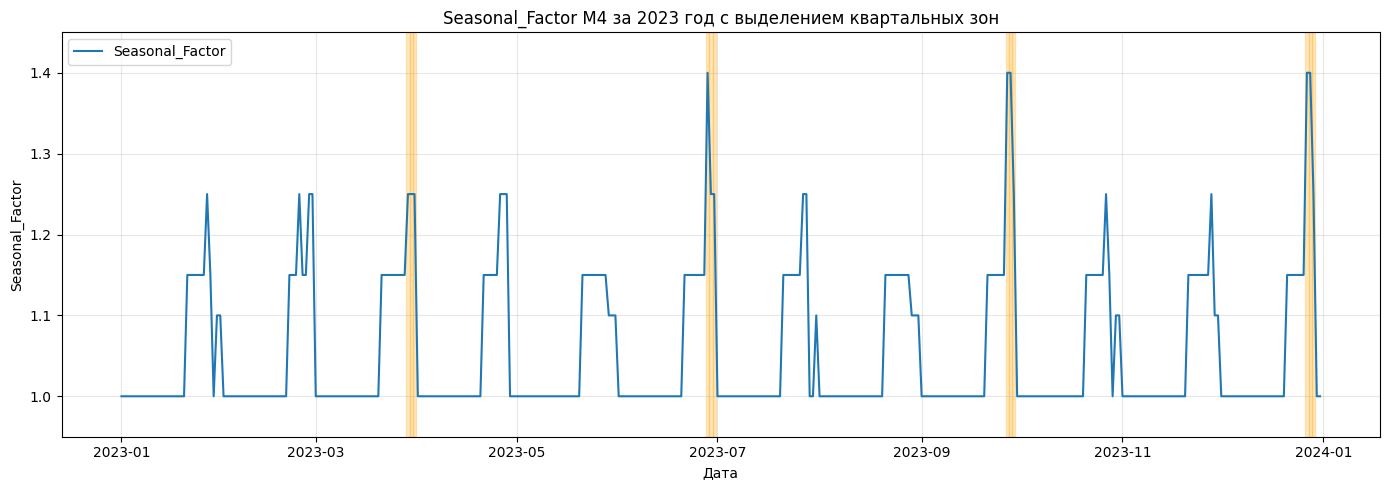

Сохранено в ../../data/processed/M4_features.csv


In [5]:
# Шаг 1. Генерация налогового календаря для М4
# Создаем ежедневный диапазон с 2014-01-01 по 2026-12-31
calendar = pd.date_range(start='2014-01-01', end='2026-12-31', freq='D')
df_m4 = pd.DataFrame({'date': calendar})

# Определим рабочие дни недели (понедельник=0, пятница=4)
df_m4['is_business_day'] = df_m4['date'].dt.weekday < 5

# Признак End_of_Month_Flag: последние 3 рабочих дня каждого месяца
end_of_month_flags = []
for (year, month), group in df_m4[df_m4['is_business_day']].groupby([df_m4['date'].dt.year, df_m4['date'].dt.month]):
    last_business_days = group.nlargest(3, 'date')['date']
    end_of_month_flags.extend(last_business_days)

end_of_month_set = set(end_of_month_flags)
df_m4['End_of_Month_Flag'] = df_m4['date'].isin(end_of_month_set).astype(int)

# Признак End_of_Quarter_Flag: последние 3 рабочих дня квартала (март, июнь, сентябрь, декабрь)
quarter_months = {3, 6, 9, 12}
quarter_flags = []
for (year, month), group in df_m4[(df_m4['is_business_day']) & (df_m4['date'].dt.month.isin(quarter_months))].groupby([df_m4['date'].dt.year, df_m4['date'].dt.month]):
    last_business_days = group.nlargest(3, 'date')['date']
    quarter_flags.extend(last_business_days)

quarter_set = set(quarter_flags)
df_m4['End_of_Quarter_Flag'] = df_m4['date'].isin(quarter_set).astype(int)

# Признак Tax_Week_Flag: 21-28 числа каждого месяца
# Это приближенная логика, отражающая пиковые налоговые недели
df_m4['Tax_Week_Flag'] = df_m4['date'].dt.day.between(21, 28).astype(int)

# Шаг 2. Расчет Seasonal_Factor на основе эвристики
# Базовый фактор 1.0, затем прибавляем штрафы за налоговые периоды и кварталы
base_factor = 1.0
seasonal = (
    base_factor
    + 0.15 * df_m4['Tax_Week_Flag']
    + 0.10 * df_m4['End_of_Month_Flag']
    + 0.15 * df_m4['End_of_Quarter_Flag']
)
df_m4['Seasonal_Factor'] = seasonal.clip(lower=1.0, upper=1.4)

# Удалим временный признак, чтобы сохранить только финальные колонки
df_m4 = df_m4[['date', 'Tax_Week_Flag', 'End_of_Month_Flag', 'End_of_Quarter_Flag', 'Seasonal_Factor']]

# Шаг 3. Условное взвешивание для уменьшения двойного счета
# Аналитическое обоснование:
# Налоговый эффект уже частично отражается в М1, М2 и М5 через баланс ликвидности и рыночные ставки.
# Поэтому используем подход "Условного взвешивания":
# если мы находимся в налоговой неделе, уменьшаем вклад сырых MAD-сигналов, чтобы не интерпретировать налоговый пик как кризис.
# Это уменьшает вероятность ложных тревог, связанных с обычными налоговыми выплатами.

def apply_conditional_weighting(raw_m1, raw_m2, raw_m5, tax_week_flag, penalty=0.3):
    """Корректирует сырые MAD-оценки в налоговую неделю.

    Если Tax_Week_Flag == 1, то понижает веса на penalty (например, на 30%).
    Это не отменяет сигнал полностью, но снижает его значимость.
    """
    if tax_week_flag == 1:
        return raw_m1 * (1 - penalty), raw_m2 * (1 - penalty), raw_m5 * (1 - penalty)
    return raw_m1, raw_m2, raw_m5

# Пример применения в агрегационном слое LSI:
# raw_m1, raw_m2, raw_m5 = get_raw_mad_scores(date)
# adjusted_m1, adjusted_m2, adjusted_m5 = apply_conditional_weighting(raw_m1, raw_m2, raw_m5, tax_week_flag)
# final_score = weighted_sum(adjusted_m1, adjusted_m2, adjusted_m5)

# Шаг 4. Визуализация за 2023 год и сохранение
subset_2023 = df_m4[(df_m4['date'] >= '2023-01-01') & (df_m4['date'] <= '2023-12-31')].copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(subset_2023['date'], subset_2023['Seasonal_Factor'], label='Seasonal_Factor', color='#1f77b4')

# Подсветка зон End_of_Quarter
for _, row in subset_2023[subset_2023['End_of_Quarter_Flag'] == 1].iterrows():
    ax.axvspan(row['date'] - pd.Timedelta(days=0.5), row['date'] + pd.Timedelta(days=0.5),
               color='orange', alpha=0.25)

ax.set_title('Seasonal_Factor М4 за 2023 год с выделением квартальных зон')
ax.set_xlabel('Дата')
ax.set_ylabel('Seasonal_Factor')
ax.set_ylim(0.95, 1.45)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Сохраним результат в CSV с датой в формате YYYY-MM-DD
df_m4_to_save = df_m4.copy()
df_m4_to_save['date'] = df_m4_to_save['date'].dt.strftime('%Y-%m-%d')
df_m4_to_save.to_csv('../../data/processed/M4_features.csv', index=False)
print('Сохранено в ../../data/processed/M4_features.csv')

График: Он выглядит именно так, как должен выглядеть "Контекстуализатор".
Базовая линия лежит на 1.0 (обычные дни).
Мы видим регулярные "столы" на уровне 1.15 — это те самые даты с 21 по 28 число (налоговая неделя).
Мы видим "иголки", пробивающие потолок (до 1.4) ровно 4 раза в год (конец марта, июня, сентября, декабря) — это конец квартала, когда налоги максимальны.
Почему это круто для ML: Эта фича детерминирована. Она не шумит. Ты просто передаешь этот мультипликатор Seasonal_Factor в финальный агрегатор. Если Factor > 1.1, модель понимает: "Ага, сейчас налоги, я должна снизить панику".

Наше решение — Штраф (Условное взвешивание) — это классический квантовый (Quant) подход. Ты говоришь модели: "Если сейчас даты с 21 по 28 число, не паникуй. Снизь чувствительность (веса) сигналов из М1 и М2 на 30%, потому что это просто налоги". Жюри (особенно из ЦБ) будут в восторге от такого ответа.

Касателно использования остатков: их можно было бы использовать в первом или втором модуле, тогда бы мы нашли тот самый "чистый шок" и на нем бы уже считали mad score, а сезонность тоже уже бы была и 4 модуль возможно даже и не понадобился. Но поскольку мы имеем дело с финансовыми рядами, в которых в разное время разнная сезонность (стоит ли использовать оконный подход?) мы не сможем качественно за короткое время декомпозировать ряд, следовательно, работаем с 4 модулем

я нашел комментарии по работе друга, просмотри их и выскажи развернуто свое
мнение:

1)  Файл data/processed/m4_dataset.csv построен из официального календаря ФНС

(https://www.nalog.gov.ru/rn77/calendar/) с разрешением выходных

и учётом всех типов событий: уплата, сдача отчётности, уведомления.

Структура:

date                          — дата (ежедневная сетка)

is_tax_payment_day            — есть ли уплата налога в этот день (0/1)

is_tax_reporting_day          — сдача отчётности (0/1)

is_notification_day           — день уведомлений (0/1)

tax_events_count              — общее число налоговых событий в день

tax_payment_events_count      — число платежей (с учётом разных налогов)

tax_reporting_events_count    — число отчётов

notification_events_count     — число уведомлений

other_events_count            — прочие события

days_to_next_tax_payment      — дней до следующей уплаты

days_since_prev_tax_payment   — дней от предыдущей уплаты

is_month_end                  — последний день месяца (0/1)

is_quarter_end                — последний день квартала (0/1)

is_year_end                   — последний день года (0/1)

2)  ЭКОНОМИЧЕСКИЙ СМЫСЛ:

1 января 2023 в РФ заработал режим ЕНП (единый налоговый платёж):

почти все основные платежи юрлиц были перенесены на 28 число.

До 2023 платежи были распределены: 15-го — взносы, 20-го — НДС,

25-го — акцизы, 28-го — налог на прибыль.

После реформы концентрация на 28-м резко возросла —

отток с корсчетов в этот день стал острее.

Без regime split STL-декомпозиция размажет сезонность —

она увидит "немного отток везде" вместо "сильный отток на 28-м".

Поэтому мы помечаем режимы и можем при необходимости

делать STL отдельно по периодам.

Также важно: если 28-е попадает на выходной/праздник,

уплата сдвигается на следующий рабочий день.

Датасет уже разрешает эти сдвиги, но мы явно проверяем.

3)  ЯЧЕЙКА 4 — Флаги налоговых окон (Pre / Active / Post)

ЭКОНОМИЧЕСКИЙ СМЫСЛ:

Поведение банковской ликвидности вокруг налоговой даты неоднородное:

PRE  (-3..-1 день до уплаты):

Клиенты-юрлица аккумулируют рубли на расчётных счетах.

Банки видят рост входящих остатков — это короткое окно

избытка ликвидности перед оттоком. M1 спред может временно расти.

ACTIVE (день уплаты):

Деньги переводятся на ЕКС. Резкий отток с корсчетов.

M2 (репо ЦБ) спрос растёт, M3 (ОФЗ) cover ratio падает.

POST (+1..+3 после уплаты):

Восстановление ликвидности.

Казначейство (M5) часто размещает накопленные на ЕКС излишки

обратно через депозитные аукционы — приток в систему.

Бинарные флаги дают ML-модели чёткую структуру для разделения этих фаз.

Окно ±3 дня — стандарт для российского рынка

(более узкое окно теряет часть эффекта pre-funding,

более широкое — захватывает чужой шум).

4)ЭКОНОМИЧЕСКИЙ СМЫСЛ:

Бинарные флаги хороши, но ML работает лучше с непрерывными признаками.

Они также позволяют различать "мягкий" tax_period (один маленький платёж)

и "жёсткий" (квартальный налог на прибыль + ЕНП в одну дату).

1. tax_proximity ∈ [0, 1]:

Экспоненциальное затухание расстояния до ближайшей tax-даты.

proximity = exp(-d/3), где d — минимум до прошлой и до следующей.

На самой дате = 1.0, через 3 дня ≈ 0.37, через 7 дней ≈ 0.10.

Гладкая замена бинарного Tax_Week_Flag.

2. tax_pressure ∈ [0, 3]:

Взвешенная сумма событий с учётом их веса по типу.

Большое число событий в одной дате (>15) = квартальный налог,

>25 = годовой налог + ЕНП — самые тяжёлые дни года.

Учитывает quarter_end и year_end как дополнительный множитель.

3. tax_pressure_smoothed:

Скользящее среднее за 7 дней — для устранения дневного шума

при использовании в ML-модели агрегатора.

5)# ЯЧЕЙКА 6 — Seasonal_Factor (1.0–1.4)

ЭКОНОМИЧЕСКИЙ СМЫСЛ:

Финальный выход модуля — один скаляр-мультипликатор для агрегационного слоя.

По требованию ТЗ Seasonal_Factor применяется НЕ аддитивно к LSI,

а как поправка контекста: "насколько ожидаемой была нагрузка в этот день".

Формула (откалибрована эмпирически):

base                                = 1.0

+ 0.15 если Tax_Week_Flag           — стандартное налоговое окно

+ 0.10 если is_quarter_end          — квартальное закрытие

+ 0.20 если is_year_end             — годовое закрытие (самое тяжёлое)

+ 0.05 если попало на holiday-shift — усиление за счёт сдвига

clip [1.0, 1.4]

Smoothed-версия — для ML (без резких прыжков от 1.0 к 1.4).

6)  ЯЧЕЙКА 7 — MAD-нормализация фич М4 (для агрегатора)

ЭКОНОМИЧЕСКИЙ СМЫСЛ:

Бинарные флаги в агрегатор идут как есть (нормализовать их не имеет смысла).

А вот непрерывные фичи (tax_pressure, tax_pressure_smoothed) полезно

нормализовать через MAD, чтобы они приходили в LSI в единых единицах

с другими модулями.

Окно — 3 года (≈1095 дней для daily-данных).

Используем тот же mad_score что в М1 для совместимости.

7)ЯЧЕЙКА 12 — Подключение реального M1 и ручная STL-декомпозиция

ТЗ по М4 требует показать пересечение налогового календаря с M1/M2/M5

и предложить способ убрать двойной счёт. Здесь используем НЕ симуляцию,

а готовый feature dataset модуля M1:

data/processed/m1_features.csv

Берём реальные ряды:

spread             — запас/дефицит относительно усредняемых резервов

ruonia_period_avg  — средняя RUONIA за период усреднения

STL-ДЕКОМПОЗИЦИЯ (ручная, без statsmodels):

trend    — скользящая медиана 13 месяцев (центрированная)

seasonal — среднее отклонение от тренда по календарному месяцу

resid    — остаток = ряд − trend − seasonal

Идея для устранения двойного счёта:

налоговая сезонность остаётся в М4 как Seasonal_Factor,

а M1 для стресс-сигнала использует residual-компоненту.
